# Link Property Prediction with GraphSAGE on ogbl-collab

In [3]:
!pip install torch_geometric ogb -q
import torch
!pip install torch_scatter torch_sparse -f https://data.pyg.org/whl/torch-{torch.__version__}.html -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 17.5 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.8/78.8 kB 5.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 84.4 MB/s eta 0:00:0000:010:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 31.8 MB/s eta 0:00:00a 0:00:01


In [4]:
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torch_geometric.transforms as T
from torch_geometric.nn import SAGEConv
from torch_geometric.utils import to_undirected
from ogb.linkproppred import PygLinkPropPredDataset, Evaluator
import numpy as np
import matplotlib.pyplot as plt
import os

# Fix PyTorch 2.6+ weights_only default for OGB files
_original_torch_load = torch.load
torch.load = lambda *args, **kwargs: _original_torch_load(
    *args, **{**kwargs, 'weights_only': False})

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

PyTorch version: 2.10.0+cu128
CUDA available: True
Using device: cuda


## 1. Dataset Loading

In [5]:
dataset = PygLinkPropPredDataset(name='ogbl-collab',
                                 root='/kaggle/working/ogb_data')
data = dataset[0]

# Debug: inspect what fields are available
print("Data object:", data)
print(f"\nNumber of nodes: {data.num_nodes:,}")
print(f"Number of edges: {data.num_edges:,}")
print(f"Node feature dim: {data.x.shape[1]}")

Downloaded 0.11 GB: 100%|██████████| 117/117 [00:03<00:00, 38.67it/s]


Extracting /kaggle/working/ogb_data/collab.zip


Processing...


Loading necessary files...
This might take a while.
Processing graphs...


100%|██████████| 1/1 [00:00<00:00, 43.37it/s]


Converting graphs into PyG objects...


100%|██████████| 1/1 [00:00<00:00, 223.99it/s]

Saving...



Done!


Data object: Data(num_nodes=235868, edge_index=[2, 2358104], x=[235868, 128], edge_weight=[2358104, 1], edge_year=[2358104, 1])

Number of nodes: 235,868
Number of edges: 2,358,104
Node feature dim: 128


## 2. Data Preparation

In [6]:
split_edge = dataset.get_edge_split()

print(f"Training edges:   {split_edge['train']['edge'].shape[0]:,}")
print(f"Validation edges: {split_edge['valid']['edge'].shape[0]:,}")
print(f"Validation neg:   {split_edge['valid']['edge_neg'].shape[0]:,}")
print(f"Test edges:       {split_edge['test']['edge'].shape[0]:,}")
print(f"Test neg:         {split_edge['test']['edge_neg'].shape[0]:,}")

Training edges:   1,179,052
Validation edges: 60,084
Validation neg:   100,000
Test edges:       46,329
Test neg:         100,000


In [7]:
# Get edge_index from the data object
# Depending on OGB/PyG version it may be stored differently
if data.edge_index is not None:
    edge_index = data.edge_index
else:
    # Rebuild from training split
    train_edge = split_edge['train']['edge']
    edge_index = train_edge.t().contiguous()
    edge_index = to_undirected(edge_index)
    print("Rebuilt edge_index from training split")

print(f"Training edge_index shape: {edge_index.shape}")

# Training adjacency = just edge_index
data.train_edge_index = edge_index

# Full adjacency (train + val edges) for test-time inference (OGB convention)
val_edge_index = split_edge['valid']['edge'].t()
full_edge_index = torch.cat([edge_index, val_edge_index], dim=-1)
data.full_edge_index = to_undirected(full_edge_index)

print(f"Full edge_index shape (train+val): {data.full_edge_index.shape}")

data = data.to(device)
print("Data moved to device.")

Training edge_index shape: torch.Size([2, 2358104])
Full edge_index shape (train+val): torch.Size([2, 1999288])
Data moved to device.


## 3. Model Architecture

In [8]:
class GraphSAGE(torch.nn.Module):
    """GraphSAGE encoder for learning node embeddings."""
    def __init__(self, in_channels, hidden_channels, out_channels, 
                 num_layers, dropout):
        super(GraphSAGE, self).__init__()
        self.convs = torch.nn.ModuleList()
        self.convs.append(SAGEConv(in_channels, hidden_channels))
        for _ in range(num_layers - 2):
            self.convs.append(SAGEConv(hidden_channels, hidden_channels))
        self.convs.append(SAGEConv(hidden_channels, out_channels))
        self.dropout = dropout

    def reset_parameters(self):
        for conv in self.convs:
            conv.reset_parameters()

    def forward(self, x, edge_index):
        for conv in self.convs[:-1]:
            x = conv(x, edge_index)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.convs[-1](x, edge_index)
        return x


class LinkPredictor(torch.nn.Module):
    """MLP link predictor: scores a pair of node embeddings."""
    def __init__(self, in_channels, hidden_channels, out_channels, 
                 num_layers, dropout):
        super(LinkPredictor, self).__init__()
        self.lins = torch.nn.ModuleList()
        self.lins.append(torch.nn.Linear(in_channels, hidden_channels))
        for _ in range(num_layers - 2):
            self.lins.append(torch.nn.Linear(hidden_channels, hidden_channels))
        self.lins.append(torch.nn.Linear(hidden_channels, out_channels))
        self.dropout = dropout

    def reset_parameters(self):
        for lin in self.lins:
            lin.reset_parameters()

    def forward(self, x_i, x_j):
        x = x_i * x_j  # element-wise product
        for lin in self.lins[:-1]:
            x = lin(x)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.lins[-1](x)
        return torch.sigmoid(x)


print("Models defined: GraphSAGE encoder + LinkPredictor MLP")

Models defined: GraphSAGE encoder + LinkPredictor MLP


## 4. Training Setup

In [28]:
# Hyperparameters
NUM_LAYERS = 3
HIDDEN_CHANNELS = 128
DROPOUT = 0.0
LR = 0.01
EPOCHS = 200
BATCH_SIZE = 64 * 1024
EVAL_STEPS = 10

model = GraphSAGE(data.num_features, HIDDEN_CHANNELS, HIDDEN_CHANNELS,
                  NUM_LAYERS, DROPOUT).to(device)
predictor = LinkPredictor(HIDDEN_CHANNELS, HIDDEN_CHANNELS, 1,
                          NUM_LAYERS, DROPOUT).to(device)

optimizer = torch.optim.Adam(
    list(model.parameters()) + list(predictor.parameters()), lr=LR)

evaluator = Evaluator(name='ogbl-collab')

total_params = sum(p.numel() for p in model.parameters()) + \
               sum(p.numel() for p in predictor.parameters())
print(f"Total trainable parameters: {total_params:,}")

Total trainable parameters: 131,841


## 5. Training & Evaluation Functions

In [29]:
def train(model, predictor, data, split_edge, optimizer, batch_size):
    model.train()
    predictor.train()

    pos_train_edge = split_edge['train']['edge'].to(data.x.device)
    total_loss = total_examples = 0

    for perm in DataLoader(range(pos_train_edge.size(0)), batch_size,
                           shuffle=True):
        optimizer.zero_grad()

        h = model(data.x, data.train_edge_index)

        edge = pos_train_edge[perm].t()
        pos_out = predictor(h[edge[0]], h[edge[1]])
        pos_loss = -torch.log(pos_out + 1e-15).mean()

        # Random negative sampling
        edge = torch.randint(0, data.num_nodes, edge.size(),
                             dtype=torch.long, device=h.device)
        neg_out = predictor(h[edge[0]], h[edge[1]])
        neg_loss = -torch.log(1 - neg_out + 1e-15).mean()

        loss = pos_loss + neg_loss
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        torch.nn.utils.clip_grad_norm_(predictor.parameters(), 1.0)
        optimizer.step()

        num_examples = pos_out.size(0)
        total_loss += loss.item() * num_examples
        total_examples += num_examples

    return total_loss / total_examples


@torch.no_grad()
def test(model, predictor, data, split_edge, evaluator, batch_size):
    model.eval()
    predictor.eval()

    # Use training adjacency for train/val predictions
    h = model(data.x, data.train_edge_index)

    pos_train_edge = split_edge['train']['edge'].to(h.device)
    pos_valid_edge = split_edge['valid']['edge'].to(h.device)
    neg_valid_edge = split_edge['valid']['edge_neg'].to(h.device)
    pos_test_edge  = split_edge['test']['edge'].to(h.device)
    neg_test_edge  = split_edge['test']['edge_neg'].to(h.device)

    pos_train_preds = []
    for perm in DataLoader(range(pos_train_edge.size(0)), batch_size):
        edge = pos_train_edge[perm].t()
        pos_train_preds.append(predictor(h[edge[0]], h[edge[1]]).squeeze().cpu())
    pos_train_pred = torch.cat(pos_train_preds, dim=0)

    pos_valid_preds = []
    for perm in DataLoader(range(pos_valid_edge.size(0)), batch_size):
        edge = pos_valid_edge[perm].t()
        pos_valid_preds.append(predictor(h[edge[0]], h[edge[1]]).squeeze().cpu())
    pos_valid_pred = torch.cat(pos_valid_preds, dim=0)

    neg_valid_preds = []
    for perm in DataLoader(range(neg_valid_edge.size(0)), batch_size):
        edge = neg_valid_edge[perm].t()
        neg_valid_preds.append(predictor(h[edge[0]], h[edge[1]]).squeeze().cpu())
    neg_valid_pred = torch.cat(neg_valid_preds, dim=0)

    # Use full adjacency (train + val) for test predictions (OGB convention)
    h_full = model(data.x, data.full_edge_index)

    pos_test_preds = []
    for perm in DataLoader(range(pos_test_edge.size(0)), batch_size):
        edge = pos_test_edge[perm].t()
        pos_test_preds.append(predictor(h_full[edge[0]], h_full[edge[1]]).squeeze().cpu())
    pos_test_pred = torch.cat(pos_test_preds, dim=0)

    neg_test_preds = []
    for perm in DataLoader(range(neg_test_edge.size(0)), batch_size):
        edge = neg_test_edge[perm].t()
        neg_test_preds.append(predictor(h_full[edge[0]], h_full[edge[1]]).squeeze().cpu())
    neg_test_pred = torch.cat(neg_test_preds, dim=0)

    results = {}
    for K in [10, 50, 100]:
        evaluator.K = K

        train_hits = evaluator.eval({
            'y_pred_pos': pos_train_pred,
            'y_pred_neg': neg_valid_pred,
        })[f'hits@{K}']

        valid_hits = evaluator.eval({
            'y_pred_pos': pos_valid_pred,
            'y_pred_neg': neg_valid_pred,
        })[f'hits@{K}']

        test_hits = evaluator.eval({
            'y_pred_pos': pos_test_pred,
            'y_pred_neg': neg_test_pred,
        })[f'hits@{K}']

        results[f'Hits@{K}'] = (train_hits, valid_hits, test_hits)

    return results


print("Training and evaluation functions ready.")

Training and evaluation functions ready.


## 6. Training Loop

In [30]:
best_val_hits = 0
save_path = '/kaggle/working/graphsage_link_best.pt'

history = {
    'epoch': [], 'loss': [],
    'train_hits10': [], 'val_hits10': [], 'test_hits10': [],
    'train_hits50': [], 'val_hits50': [], 'test_hits50': [],
    'train_hits100': [], 'val_hits100': [], 'test_hits100': [],
}

for epoch in range(1, EPOCHS + 1):
    loss = train(model, predictor, data, split_edge, optimizer, BATCH_SIZE)

    if epoch % EVAL_STEPS == 0:
        results = test(model, predictor, data, split_edge, evaluator,
                       BATCH_SIZE)
        
        train_hits50 = results['Hits@50'][0]
        val_hits50   = results['Hits@50'][1]
        test_hits50  = results['Hits@50'][2]

        history['epoch'].append(epoch)
        history['loss'].append(loss)
        for K in [10, 50, 100]:
            tr, va, te = results[f'Hits@{K}']
            history[f'train_hits{K}'].append(tr)
            history[f'val_hits{K}'].append(va)
            history[f'test_hits{K}'].append(te)

        print(f"Epoch {epoch:03d} | Loss: {loss:.4f} | "
              f"Train Hits@50: {100*train_hits50:.2f}% | "
              f"Val Hits@50: {100*val_hits50:.2f}% | "
              f"Test Hits@50: {100*test_hits50:.2f}%")

        if val_hits50 > best_val_hits:
            best_val_hits = val_hits50
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'predictor_state_dict': predictor.state_dict(),
                'val_hits50': val_hits50,
            }, save_path)
            print(f"  -> New best model saved (Val Hits@50: {100*val_hits50:.2f}%)")

print(f"\nTraining complete. Best Val Hits@50: {100*best_val_hits:.2f}%")

Epoch 010 | Loss: 0.2714 | Train Hits@50: 8.04% | Val Hits@50: 2.51% | Test Hits@50: 3.30%
  -> New best model saved (Val Hits@50: 2.51%)
Epoch 020 | Loss: 0.1337 | Train Hits@50: 38.39% | Val Hits@50: 22.19% | Test Hits@50: 16.35%
  -> New best model saved (Val Hits@50: 22.19%)
Epoch 030 | Loss: 0.1135 | Train Hits@50: 38.19% | Val Hits@50: 20.98% | Test Hits@50: 18.93%
Epoch 040 | Loss: 0.1166 | Train Hits@50: 36.58% | Val Hits@50: 18.47% | Test Hits@50: 13.47%
Epoch 050 | Loss: 0.0678 | Train Hits@50: 65.69% | Val Hits@50: 37.71% | Test Hits@50: 35.88%
  -> New best model saved (Val Hits@50: 37.71%)
Epoch 060 | Loss: 0.0708 | Train Hits@50: 69.00% | Val Hits@50: 40.10% | Test Hits@50: 32.88%
  -> New best model saved (Val Hits@50: 40.10%)
Epoch 070 | Loss: 0.1033 | Train Hits@50: 45.44% | Val Hits@50: 26.71% | Test Hits@50: 22.49%
Epoch 080 | Loss: 0.0678 | Train Hits@50: 64.56% | Val Hits@50: 37.24% | Test Hits@50: 32.44%
Epoch 090 | Loss: 0.0589 | Train Hits@50: 68.57% | Val Hits@

## 7. Final Evaluation

In [31]:
checkpoint = torch.load(save_path)
model.load_state_dict(checkpoint['model_state_dict'])
predictor.load_state_dict(checkpoint['predictor_state_dict'])

final_results = test(model, predictor, data, split_edge, evaluator, BATCH_SIZE)

print(f"Best model from epoch {checkpoint['epoch']}")
print(f"{'Metric':<12} {'Train':>10} {'Valid':>10} {'Test':>10}")
print("-" * 44)
for key in ['Hits@10', 'Hits@50', 'Hits@100']:
    tr, va, te = final_results[key]
    print(f"{key:<12} {100*tr:>9.2f}% {100*va:>9.2f}% {100*te:>9.2f}%")

Best model from epoch 190
Metric            Train      Valid       Test
--------------------------------------------
Hits@10          50.04%     24.81%     24.04%
Hits@50          85.44%     50.21%     49.44%
Hits@100         90.65%     55.43%     55.97%


## 8. Visualizations

### Training Curves

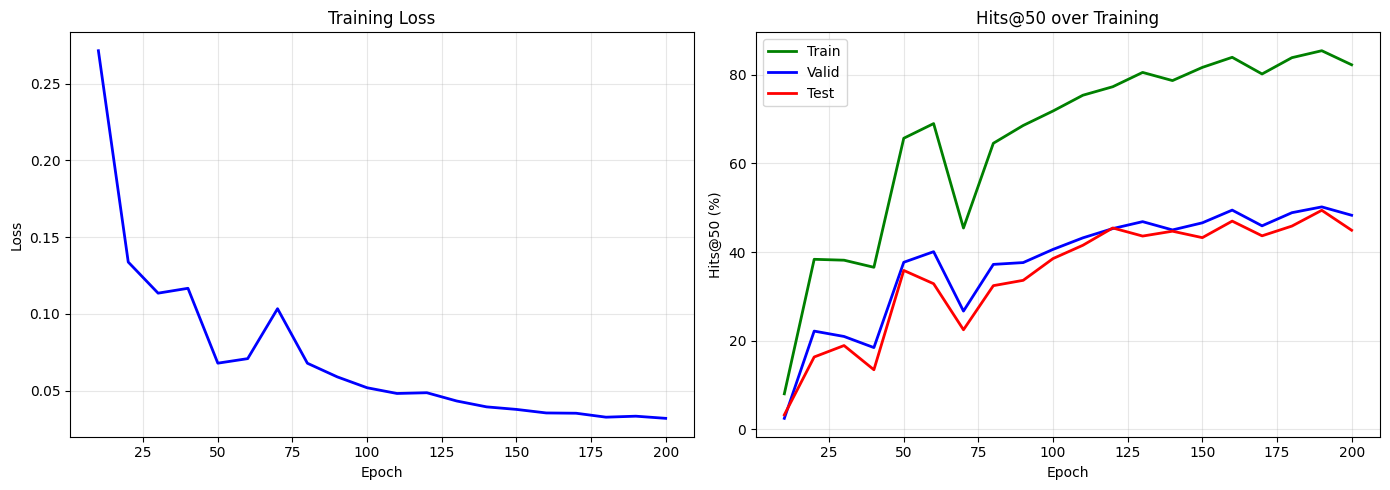

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curve
axes[0].plot(history['epoch'], history['loss'], 'b-', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss')
axes[0].grid(True, alpha=0.3)

# Hits@50 curves
axes[1].plot(history['epoch'], [x*100 for x in history['train_hits50']], 
             'g-', label='Train', linewidth=2)
axes[1].plot(history['epoch'], [x*100 for x in history['val_hits50']], 
             'b-', label='Valid', linewidth=2)
axes[1].plot(history['epoch'], [x*100 for x in history['test_hits50']], 
             'r-', label='Test', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Hits@50 (%)')
axes[1].set_title('Hits@50 over Training')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

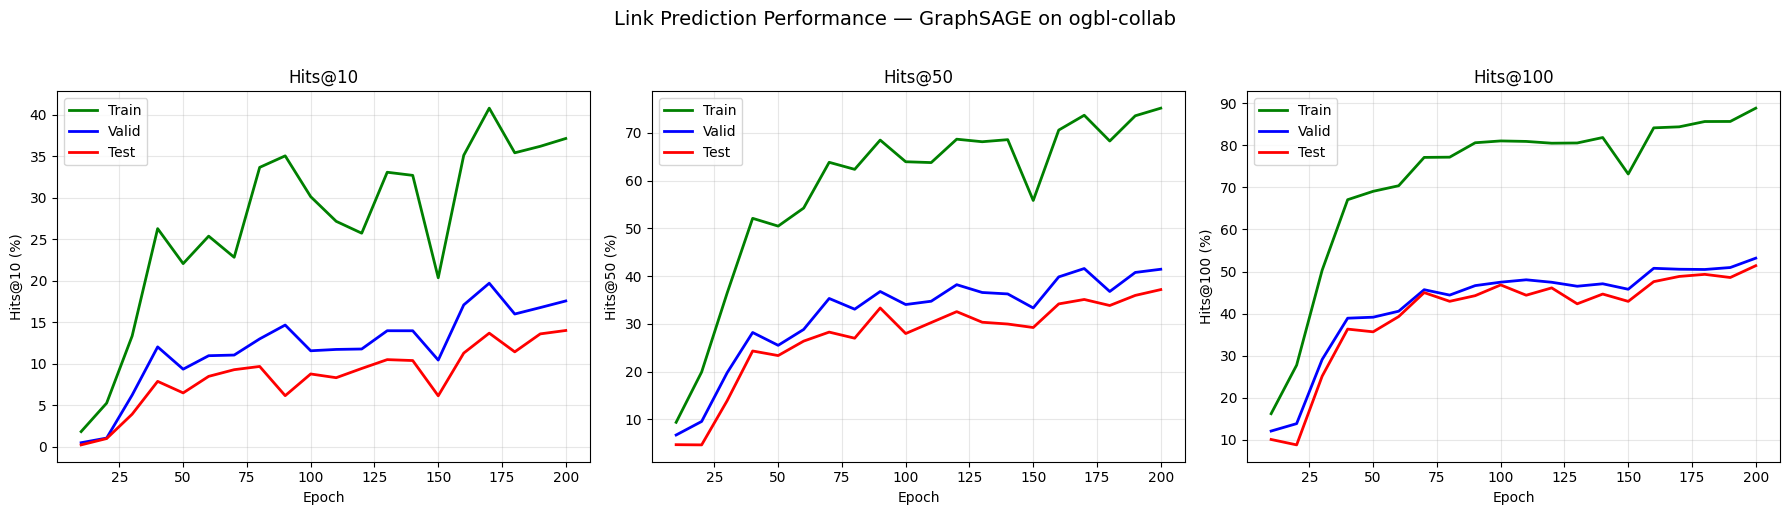

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, K in enumerate([10, 50, 100]):
    axes[i].plot(history['epoch'], [x*100 for x in history[f'train_hits{K}']], 
                 'g-', label='Train', linewidth=2)
    axes[i].plot(history['epoch'], [x*100 for x in history[f'val_hits{K}']], 
                 'b-', label='Valid', linewidth=2)
    axes[i].plot(history['epoch'], [x*100 for x in history[f'test_hits{K}']], 
                 'r-', label='Test', linewidth=2)
    axes[i].set_xlabel('Epoch')
    axes[i].set_ylabel(f'Hits@{K} (%)')
    axes[i].set_title(f'Hits@{K}')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Link Prediction Performance — GraphSAGE on ogbl-collab', 
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('/kaggle/working/hits_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### Score Distribution Analysis

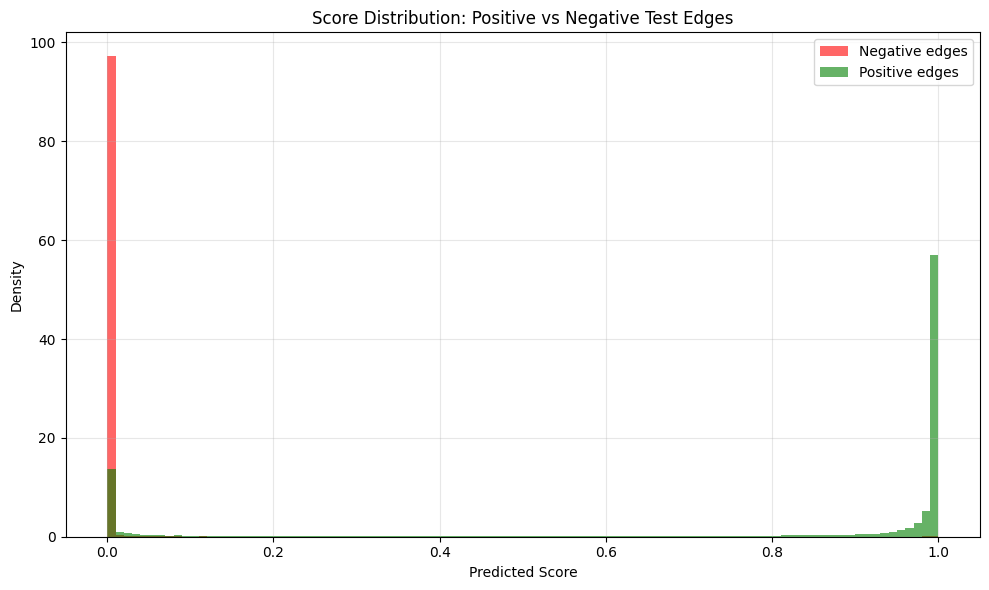

Positive edges — mean: 0.7729, std: 0.3845
Negative edges — mean: 0.0103, std: 0.0853


In [33]:
@torch.no_grad()
def get_score_distributions(model, predictor, data, split_edge, batch_size):
    """Get predicted scores for positive and negative edges."""
    model.eval()
    predictor.eval()
    
    h = model(data.x, data.full_edge_index)
    
    pos_test_edge = split_edge['test']['edge'].to(h.device)
    neg_test_edge = split_edge['test']['edge_neg'].to(h.device)
    
    pos_scores = []
    for perm in DataLoader(range(pos_test_edge.size(0)), batch_size):
        edge = pos_test_edge[perm].t()
        pos_scores.append(predictor(h[edge[0]], h[edge[1]]).squeeze().cpu())
    
    neg_scores = []
    for perm in DataLoader(range(neg_test_edge.size(0)), batch_size):
        edge = neg_test_edge[perm].t()
        neg_scores.append(predictor(h[edge[0]], h[edge[1]]).squeeze().cpu())
    
    return torch.cat(pos_scores).numpy(), torch.cat(neg_scores).numpy()

pos_scores, neg_scores = get_score_distributions(
    model, predictor, data, split_edge, BATCH_SIZE)

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(neg_scores, bins=100, alpha=0.6, label='Negative edges', 
        color='red', density=True)
ax.hist(pos_scores, bins=100, alpha=0.6, label='Positive edges', 
        color='green', density=True)
ax.set_xlabel('Predicted Score')
ax.set_ylabel('Density')
ax.set_title('Score Distribution: Positive vs Negative Test Edges')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/kaggle/working/score_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Positive edges — mean: {pos_scores.mean():.4f}, std: {pos_scores.std():.4f}")
print(f"Negative edges — mean: {neg_scores.mean():.4f}, std: {neg_scores.std():.4f}")

### Node Embedding Visualization (t-SNE)

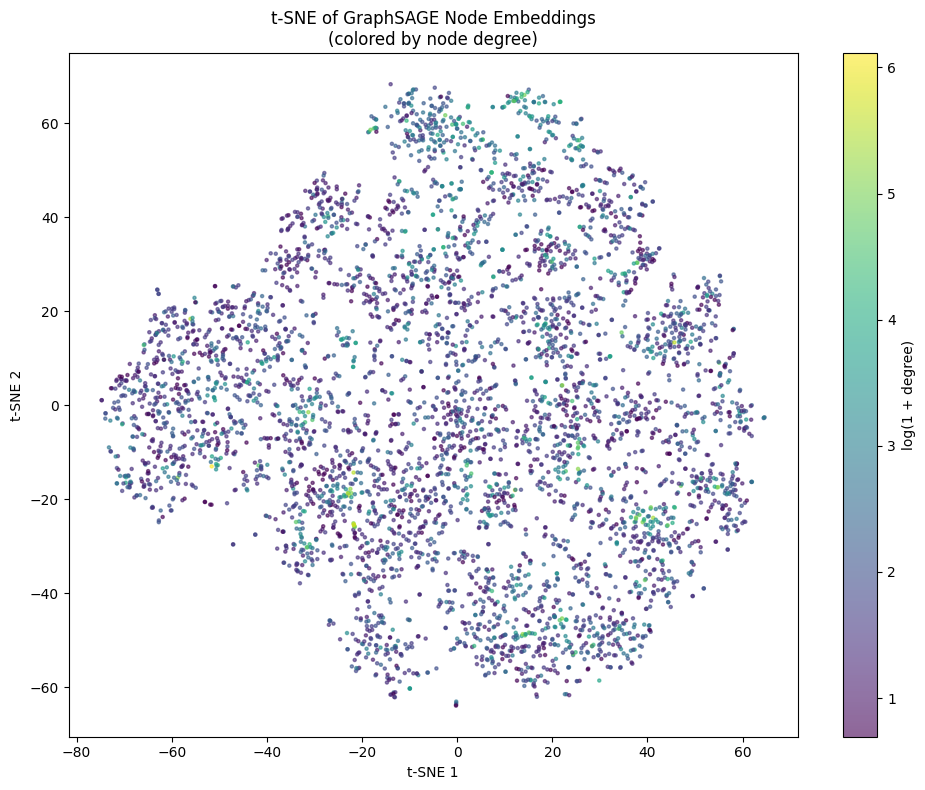

In [34]:
from sklearn.manifold import TSNE

@torch.no_grad()
def get_embeddings(model, data, num_nodes=5000):
    model.eval()
    h = model(data.x, data.train_edge_index)
    # Sample random nodes for visualization
    idx = torch.randperm(h.size(0))[:num_nodes]
    return h[idx].cpu().numpy(), idx.cpu().numpy()

embeddings, node_idx = get_embeddings(model, data, num_nodes=5000)

# Compute node degrees for coloring
src, dst = data.train_edge_index.cpu()
deg = torch.zeros(data.num_nodes, dtype=torch.long)
deg.scatter_add_(0, src, torch.ones_like(src))
sampled_degrees = deg[node_idx].numpy()

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
embeddings_2d = tsne.fit_transform(embeddings)

fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], 
                     c=np.log1p(sampled_degrees), cmap='viridis',
                     s=5, alpha=0.6)
plt.colorbar(scatter, ax=ax, label='log(1 + degree)')
ax.set_title('t-SNE of GraphSAGE Node Embeddings\n(colored by node degree)')
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
plt.tight_layout()
plt.savefig('/kaggle/working/tsne_embeddings.png', dpi=150, bbox_inches='tight')
plt.show()